# IMDb NLP Processor - Actividad Práctica

## Unidad 2 - Clase 1: Text Mining y Embeddings Contextuales

Esta actividad trabaja el flujo completo de procesamiento de texto sobre el dataset IMDb de Kaggle, sin usar Transformers ni modelos preentrenados.

## Objetivos de aprendizaje
- Leer y explorar un dataset real de reseñas.
- Limpiar texto de forma sistemática.
- Tokenizar y convertir a secuencias numéricas.
- Aplicar padding (pre/post) y justificar la elección.
- Visualizar una Embedding Layer y entender su salida.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Resolver raiz del proyecto de forma robusta
def find_root(start: Path) -> Path:
    for folder in [start, *start.parents]:
        if (folder / 'src').exists() and (folder / 'dataset').exists() and (folder / 'notebooks').exists():
            return folder
    raise FileNotFoundError('No se encontro la raiz de IMDb_NLP_Processor')

ROOT = find_root(Path.cwd())
SRC = ROOT / 'src'
IMAGES = ROOT / 'images'
IMAGES.mkdir(parents=True, exist_ok=True)

if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

from utils import load_imdb_dataset, sample_dataset, dataset_status
from eda import (
    add_review_length,
    basic_report,
    sentiment_distribution,
    longest_reviews,
    shortest_reviews,
    plot_sentiment_distribution,
    plot_length_histogram,
)
from preprocessing import clean_dataframe, show_before_after
from tokenizer_utils import build_tokenizer, texts_to_sequences, top_n_words, apply_padding, suggest_max_len
from embedding_utils import build_embedding_model

print('Entorno listo. ROOT =', ROOT)

Entorno listo. ROOT = /home/claude/work/IMDb_NLP_Processor


In [2]:
# --- BLOQUE OPCIONAL: ACTIVAR/CONFIGURAR GPU ---
# Si ya tienes tu entorno configurado, puedes dejarlo en False.
USE_GPU = False

if USE_GPU:
    import tensorflow as tf
    
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        # Evita que TensorFlow reserve toda la memoria de la GPU al inicio.
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU detectada(s): {len(gpus)}")
        for i, gpu in enumerate(gpus):
            print(f"  GPU {i}: {gpu.name}")
    else:
        print("No se detectó GPU. Se usará CPU.")
else:
    print("Bloque GPU opcional desactivado (USE_GPU=False).")

Bloque GPU opcional desactivado (USE_GPU=False).


## Carga del dataset
El CSV esperado es `dataset/imdb_reviews.csv` con columnas `review` y `sentiment`.

Si aún no tienes el archivo real de Kaggle, el notebook creará una muestra mínima de demostración para no bloquear el flujo, pero debes reemplazarla para la entrega final.

In [3]:
csv_path = ROOT / 'dataset' / 'imdb_reviews.csv'
df = load_imdb_dataset(csv_path)

if len(df) == 0:
    print('ADVERTENCIA: imdb_reviews.csv esta vacio. Se generara una muestra didactica temporal.')
    demo_reviews = [
        ('I loved this movie, amazing acting and story.', 'positive'),
        ('Terrible film. Waste of time.', 'negative'),
        ('Great soundtrack and emotional ending.', 'positive'),
        ('The plot was boring and predictable.', 'negative'),
        ('Excellent direction and characters.', 'positive'),
        ('Poor script and weak dialogues.', 'negative'),
        ('Fantastic cinematography, highly recommended.', 'positive'),
        ('I did not enjoy it at all.', 'negative'),
        ('A masterpiece of modern cinema.', 'positive'),
        ('Bad pacing and confusing scenes.', 'negative'),
    ]
    df = pd.DataFrame(demo_reviews, columns=['review', 'sentiment'])

print('Estado del dataset:', dataset_status(df))
display(df.head())

Estado del dataset: registros=50000, columnas=2, nulos_total=0


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## Muestreo opcional para acelerar práctica
Puedes elegir entre usar todo el dataset o tomar una muestra (por ejemplo, 2,000 a 5,000 registros).

In [4]:
# Configuración de tamaño de datos
USE_ALL_SAMPLES = True  # True = usar todo el dataset | False = usar muestra
N_SAMPLES = 3000         # Solo se usa si USE_ALL_SAMPLES=False

if USE_ALL_SAMPLES:
    print('Usando TODAS las muestras del dataset.')
    # Mezcla ligera para evitar sesgo de orden
    df = df.sample(frac=1.0, random_state=42).reset_index(drop=True)
else:
    df = sample_dataset(df, n_samples=N_SAMPLES, random_state=42)
    print(f'Usando muestra de {len(df)} registros.')

print('Registros usados en la actividad:', len(df))

Usando TODAS las muestras del dataset.
Registros usados en la actividad: 50000


# Parte 1 - Exploración del Dataset (EDA)

In [5]:
report = basic_report(df)
print('Numero de registros:', report['num_records'])
print('Numero de columnas:', report['num_columns'])
print('Tipos de datos:', report['dtypes'])
print('Valores nulos:', report['nulls'])

Numero de registros: 50000
Numero de columnas: 2
Tipos de datos: {'review': 'str', 'sentiment': 'str'}
Valores nulos: {'review': 0, 'sentiment': 0}


In [6]:
df_eda = add_review_length(df, text_col='review')

dist = sentiment_distribution(df_eda, label_col='sentiment')
print('Distribucion de clases:')
print(dist)

print('\nLongitud promedio (palabras):', round(df_eda['review_len_words'].mean(), 2))
print('Longitud promedio (caracteres):', round(df_eda['review_len_chars'].mean(), 2))

Distribucion de clases:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Longitud promedio (palabras): 231.16
Longitud promedio (caracteres): 1309.43


In [7]:
print('Cinco reseñas mas largas:')
display(longest_reviews(df_eda, top_n=5))

print('Cinco reseñas mas cortas:')
display(shortest_reviews(df_eda, top_n=5))

Cinco reseñas mas largas:


,review,sentiment,review_len_words
37493,Match 1: Tag Team Table Match Bubba Ray and Sp...,positive,2470
14059,There's a sign on The Lost Highway that says:<...,positive,2278
24544,"Back in the mid/late 80s, an OAV anime by titl...",positive,2125
25102,"(Some spoilers included:)<br /><br />Although,...",positive,2108
35777,Titanic directed by James Cameron presents a f...,positive,1839


Cinco reseñas mas cortas:


,review,sentiment,review_len_words
49141,Primary plot!Primary direction!Poor interpreta...,negative,4
35300,"Read the book, forget the movie!",negative,6
35398,I hope this group of film-makers never re-unites.,negative,8
47189,"More suspenseful, more subtle, much, much more...",negative,8
5727,"What a script, what a story, what a mess!",negative,9


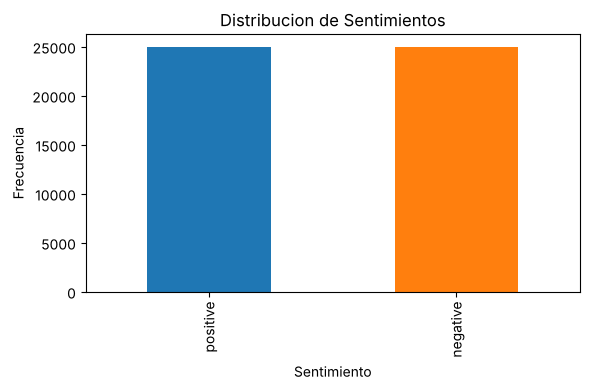

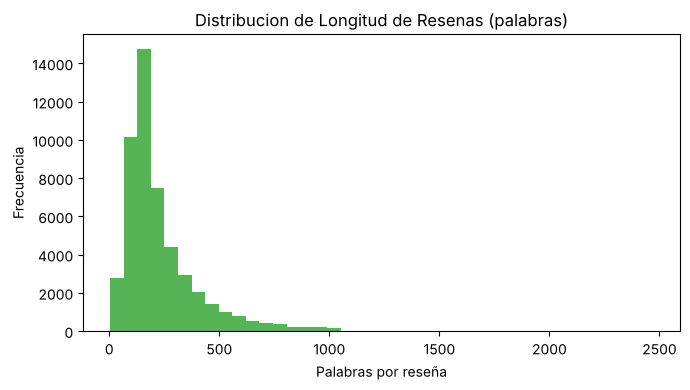

In [8]:
plot_sentiment_distribution(df_eda, save_path=str(IMAGES / 'eda_distribucion_sentimientos.png'))
plot_length_histogram(df_eda, save_path=str(IMAGES / 'eda_hist_longitud.png'))

**Interpretación sugerida:**
- Verifica si las clases están balanceadas o no.
- Evalúa si hay reseñas extremadamente largas/cortas que puedan afectar el padding.
- Identifica si conviene truncar secuencias en un percentil de longitud.

# Parte 2 - Limpieza del Texto

In [9]:
df_clean = clean_dataframe(df_eda, text_col='review')

print('Ejemplos antes y despues de limpieza:')
display(show_before_after(df_clean, n=8))

Ejemplos antes y despues de limpieza:


,review,review_clean,sentiment
0,I really liked this Summerslam due to the look...,i really liked this summerslam due to the look...,positive
1,Not many television shows appeal to quite as m...,not many television shows appeal to quite as m...,positive
2,The film quickly gets to a major chase scene w...,the film quickly gets to a major chase scene w...,negative
3,Jane Austen would definitely approve of this o...,jane austen would definitely approve of this o...,positive
4,Expectations were somewhat high for me when I ...,expectations were somewhat high for me when i ...,negative
5,I've watched this movie on a fairly regular ba...,i ve watched this movie on a fairly regular ba...,positive
6,For once a story of hope highlighted over the ...,for once a story of hope highlighted over the ...,positive
7,"Okay, I didn't get the Purgatory thing the fir...",okay i didn t get the purgatory thing the firs...,positive


**¿Por qué estas transformaciones?**
- Minúsculas: reduce variación artificial (`Great` vs `great`).
- HTML/URLs: suelen ser ruido para sentimiento en este nivel.
- Números y signos: simplifican vocabulario inicial.
- Espacios repetidos: normaliza y evita tokens vacíos.

# Parte 3 - Tokenización

In [10]:
NUM_WORDS = 20000
tokenizer = build_tokenizer(df_clean['review_clean'], num_words=NUM_WORDS, oov_token='<OOV>')
sequences = texts_to_sequences(tokenizer, df_clean['review_clean'])

print('Tamaño de vocabulario aprendido:', len(tokenizer.word_index))
print('Top 20 palabras mas frecuentes:')
for word, count in top_n_words(tokenizer, n=20):
    print(f'{word:15s} -> {count}')

print('\nEjemplos de secuencias:')
for i, (txt, seq) in enumerate(zip(df_clean['review_clean'].head(3), sequences[:3]), start=1):
    print(f'--- Ejemplo {i} ---')
    print('Texto :', txt[:140], '...')
    print('Ids   :', seq[:25])

Tamaño de vocabulario aprendido: 99294
Top 20 palabras mas frecuentes:
the             -> 668005
and             -> 324439
a               -> 323057
of              -> 289413
to              -> 268123
is              -> 211091
it              -> 190862
in              -> 186785
i               -> 175626
this            -> 151001
that            -> 143880
s               -> 129787
was             -> 95606
as              -> 91764
movie           -> 87971
for             -> 87471
with            -> 87368
but             -> 83553
film            -> 79705
you             -> 69131

Ejemplos de secuencias:
--- Ejemplo 1 ---
Texto : i really liked this summerslam due to the look of the arena the curtains and just the look overall was interesting to me for some reason any ...
Ids   : [10, 65, 425, 11, 1, 680, 6, 2, 166, 5, 2, 10367, 2, 12661, 3, 42, 2, 166, 437, 14, 220, 6, 69, 17, 49]
--- Ejemplo 2 ---
Texto : not many television shows appeal to quite as many different kinds of fans like fars

**Explicación técnica:** cada reseña se convierte en una lista de enteros según `word_index`. Ese diccionario asigna un índice único a cada palabra del vocabulario.

# Parte 4 - Padding

In [11]:
# Elegimos MAX_LEN con datos: percentil 90 de longitudes (acotado a 300 para controlar memoria)
p50 = suggest_max_len(sequences, percentile=50)
p90 = suggest_max_len(sequences, percentile=90)
MAX_LEN = min(p90, 300)
recortadas = np.mean([len(s) > MAX_LEN for s in sequences])
print(f'Longitud p50={p50} | p90={p90} -> MAX_LEN={MAX_LEN} (reseñas recortadas: {recortadas:.1%})')

pad_pre = apply_padding(sequences, max_len=MAX_LEN, padding='pre', truncating='pre')
pad_post = apply_padding(sequences, max_len=MAX_LEN, padding='post', truncating='post')

print('Antes del padding: lista de secuencias con longitudes variables')
print('Longitudes primeras 5 secuencias:', [len(s) for s in sequences[:5]])

print('\nDespues del pre-padding shape:', pad_pre.shape)
print('Despues del post-padding shape:', pad_post.shape)

print('\nEjemplo pre-padding (primeros 20):', pad_pre[0][:20])
print('Ejemplo post-padding (primeros 20):', pad_post[0][:20])

Longitud p50=176 | p90=457 -> MAX_LEN=300 (reseñas recortadas: 22.7%)


Antes del padding: lista de secuencias con longitudes variables
Longitudes primeras 5 secuencias: [203, 354, 118, 101, 337]

Despues del pre-padding shape: (50000, 300)
Despues del post-padding shape: (50000, 300)

Ejemplo pre-padding (primeros 20): [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Ejemplo post-padding (primeros 20): [   10    65   425    11     1   680     6     2   166     5     2 10367
     2 12661     3    42     2   166   437    14]


**Estrategia seleccionada:** `post-padding`.

Justificación: en reseñas suele ser útil mantener el inicio del texto (contexto inicial), y agregar ceros al final facilita inspección y comparación de ejemplos en esta etapa formativa.

**Sobre `MAX_LEN`:** se elige con el percentil 90 de las longitudes en vez de un valor arbitrario: cubre la gran mayoría de reseñas sin llenar la matriz de ceros.

# Parte 5 - Introducción a Word Embeddings

In [12]:
vocab_size = min(len(tokenizer.word_index) + 1, NUM_WORDS)
EMBEDDING_DIM = 32

model = build_embedding_model(vocab_size=vocab_size, max_len=MAX_LEN, embedding_dim=EMBEDDING_DIM)
model.summary()

X = pad_post
y = (df_clean['sentiment'].astype(str).str.lower() == 'positive').astype(int).values

print('Dimensiones de entrada X:', X.shape)
print('Dimensiones de etiquetas y:', y.shape)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 32)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 640,545 (2.44 MB)

 Trainable params: 640,545 (2.44 MB)

 Non-trainable params: 0 (0.00 B)

Dimensiones de entrada X: (50000, 300)
Dimensiones de etiquetas y: (50000,)


In [13]:
# Visualizar como una secuencia numerica se transforma en un vector final
sample_x = X[:1]
sample_out = model.predict(sample_x, verbose=0)

print('Input sample shape:', sample_x.shape)
print('Output sample shape:', sample_out.shape)
print('Output sample values:', sample_out)

Input sample shape: (1, 300)
Output sample shape: (1, 1)
Output sample values: [[0.50174564]]


**Explicación de capas:**
- `Embedding`: convierte IDs de palabras a vectores densos.
- `GlobalAveragePooling1D`: resume la secuencia en un único vector promedio.
- `Dense`: proyección lineal/no lineal mínima para obtener una salida escalar.
- `mask_zero=True`: el padding (índice 0) no participa en el promedio.
- `keras.Input(shape=(MAX_LEN,))` reemplaza a `input_length` (obsoleto en Keras 3).

# Parte 6 - Reflexión Técnica

Responde con argumentos técnicos:

1. ¿Por qué un modelo de IA no puede trabajar directamente con texto?
2. ¿Cuál es la función del Tokenizer?
3. ¿Qué representa el `word_index`?
4. ¿Por qué todas las secuencias deben tener la misma longitud?
5. ¿Qué ventaja ofrece una Embedding Layer frente a usar solo números enteros?
6. ¿Qué dificultades encontraste durante el procesamiento del dataset?

# Entrenamiento completo del modelo (enfoque de aprendizaje)
En esta sección entrenaremos un modelo más sólido para práctica real, evaluaremos su desempeño y haremos inferencia con textos escritos por el usuario.

> ⚠️ **Buena práctica:** dividimos train/test **antes** de ajustar el tokenizer, para que el vocabulario no "conozca" palabras del conjunto de prueba (fuga de información).

In [14]:
# Bloque 1: configuración general, split y tokenización SIN fuga de información
RUN_FULL_TRAINING = True

if RUN_FULL_TRAINING:
    import tensorflow as tf
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
    from sklearn.utils.class_weight import compute_class_weight

    tf.keras.utils.set_random_seed(42)

    # 1) Split de los TEXTOS (no de las secuencias): el tokenizer solo debe "ver" train
    txt_train, txt_test, y_train, y_test = train_test_split(
        df_clean['review_clean'], y, test_size=0.2, random_state=42, stratify=y
    )

    # 2) Tokenizer ajustado únicamente con train (en producción no conocemos el futuro)
    tokenizer = build_tokenizer(txt_train, num_words=NUM_WORDS, oov_token='<OOV>')
    X_train = apply_padding(texts_to_sequences(tokenizer, txt_train), max_len=MAX_LEN)
    X_test = apply_padding(texts_to_sequences(tokenizer, txt_test), max_len=MAX_LEN)
    vocab_size = min(len(tokenizer.word_index) + 1, NUM_WORDS)

    # Class weights para robustez ante posible desbalanceo
    classes = np.unique(y_train)
    class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
    class_weight_dict = {int(c): float(w) for c, w in zip(classes, class_weights)}

    # Hiperparámetros de entrenamiento
    EPOCHS = 20
    BATCH_SIZE = 64
    LEARNING_RATE = 1e-3

    print('Train shape:', X_train.shape, y_train.shape)
    print('Test shape :', X_test.shape, y_test.shape)
    print('Class weights:', class_weight_dict)
else:
    print('Entrenamiento completo desactivado. Cambia RUN_FULL_TRAINING=True para ejecutarlo.')

Train shape: (40000, 300) (40000,)
Test shape : (10000, 300) (10000,)
Class weights: {0: 1.0, 1: 1.0}


### Bloque 2: definición y compilación del modelo
Se define una arquitectura más robusta y luego se compila con métricas útiles para seguimiento del aprendizaje.

In [15]:
# Bloque 2: definición y compilación del modelo
if RUN_FULL_TRAINING:
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(MAX_LEN,)),
        tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, mask_zero=True),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
        ],
    )

    print('Resumen del modelo entrenable:')
    model.summary()

Resumen del modelo entrenable:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 300, 32)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 652,545 (2.49 MB)

 Trainable params: 652,545 (2.49 MB)

 Non-trainable params: 0 (0.00 B)

### Bloque 3: callbacks y entrenamiento
Entrenamos por más épocas con EarlyStopping y ReduceLROnPlateau para mejorar estabilidad.

La validación para EarlyStopping se toma del 10% de **train** (`validation_split`): el conjunto de test solo se usa una vez, al final.

In [16]:
# Bloque 3: callbacks y entrenamiento
if RUN_FULL_TRAINING:
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1,
        ),
    ]

    history = model.fit(
        X_train, y_train,
        validation_split=0.1,  # validación sale de train; el test queda intacto hasta el final
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=2,  # una línea por época
    )

Epoch 1/20


563/563 - 5s - 9ms/step - accuracy: 0.8289 - auc: 0.9147 - loss: 0.3728 - precision: 0.8327 - recall: 0.8236 - val_accuracy: 0.9003 - val_auc: 0.9616 - val_loss: 0.2525 - val_precision: 0.8918 - val_recall: 0.9093 - learning_rate: 0.0010


Epoch 2/20


563/563 - 5s - 8ms/step - accuracy: 0.9222 - auc: 0.9727 - loss: 0.2077 - precision: 0.9210 - recall: 0.9237 - val_accuracy: 0.8960 - val_auc: 0.9614 - val_loss: 0.2590 - val_precision: 0.8851 - val_recall: 0.9083 - learning_rate: 0.0010


Epoch 3/20


...

563/563 - 3s - 6ms/step - accuracy: 0.9466 - auc: 0.9831 - loss: 0.1570 - precision: 0.9476 - recall: 0.9455 - val_accuracy: 0.8905 - val_auc: 0.9576 - val_loss: 0.2988 - val_precision: 0.9117 - val_recall: 0.8630 - learning_rate: 0.0010


Epoch 4/20


563/563 - 4s - 7ms/step - accuracy: 0.9622 - auc: 0.9907 - loss: 0.1126 - precision: 0.9630 - recall: 0.9615 - val_accuracy: 0.8917 - val_auc: 0.9564 - val_loss: 0.3216 - val_precision: 0.8872 - val_recall: 0.8957 - learning_rate: 5.0000e-04


Epoch 4: early stopping


Restoring model weights from the end of the best epoch: 1.


### Bloque 4: métricas y curvas de entrenamiento
Evaluamos métricas principales y visualizamos las curvas para analizar el comportamiento del modelo por época.


Métricas en test:
accuracy  : 0.8898
auc       : 0.9570
loss      : 0.2673
precision : 0.8881
recall    : 0.8920


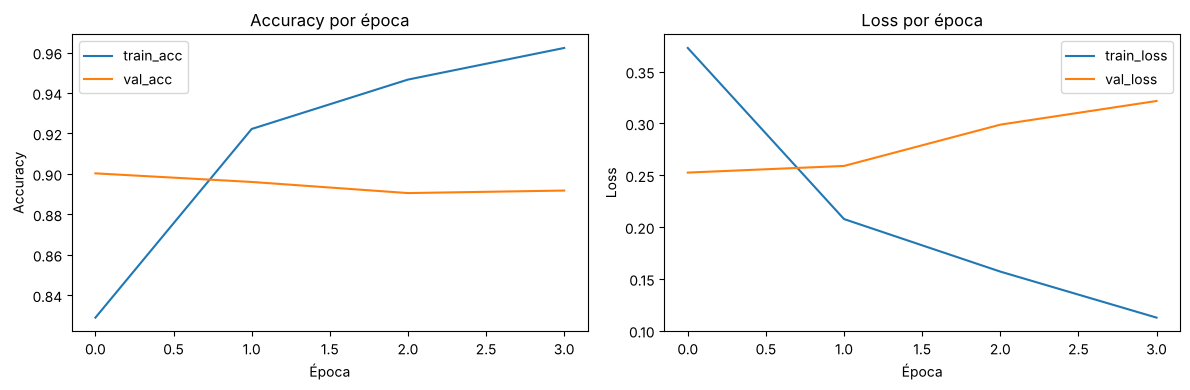

In [17]:
# Bloque 4: métricas y curvas de entrenamiento
if RUN_FULL_TRAINING:
    eval_results = model.evaluate(X_test, y_test, verbose=0, return_dict=True)
    print('\nMétricas en test:')
    for name, value in eval_results.items():
        print(f'{name:10s}: {value:.4f}')

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='train_acc')
    plt.plot(history.history['val_accuracy'], label='val_acc')
    plt.title('Accuracy por época')
    plt.xlabel('Época')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.title('Loss por época')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.savefig(IMAGES / 'training_curves.png', dpi=150)
    plt.show()

### Bloque 5: matriz de confusión y reporte de clasificación
Se evalúa la calidad del modelo con métricas por clase y una matriz de confusión.

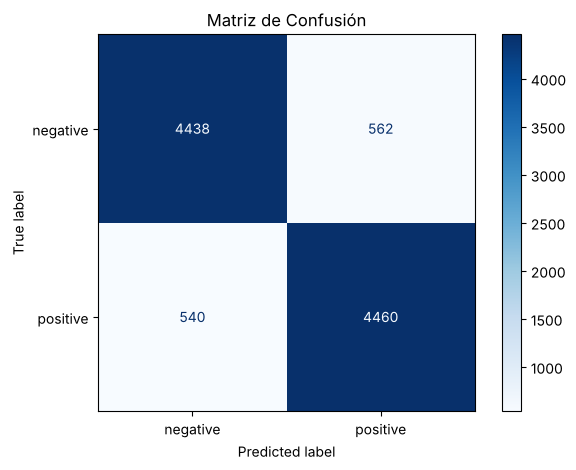


Reporte de clasificación:
              precision    recall  f1-score   support

    negative       0.89      0.89      0.89      5000
    positive       0.89      0.89      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [18]:
# Bloque 5: matriz de confusión y reporte de clasificación
if RUN_FULL_TRAINING:
    y_prob = model.predict(X_test, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['negative', 'positive'])
    disp.plot(cmap='Blues')
    plt.title('Matriz de Confusión')
    plt.tight_layout()
    plt.savefig(IMAGES / 'confusion_matrix.png', dpi=150)
    plt.show()

    print('\nReporte de clasificación:')
    print(classification_report(y_test, y_pred, target_names=['negative', 'positive']))

### Bloque 6: función de inferencia y ejemplos
Creamos una función reutilizable para predecir sentimiento sobre cualquier texto nuevo.

In [19]:
# Bloque 6: función de inferencia y ejemplos
if RUN_FULL_TRAINING:
    from preprocessing import clean_text

    def predict_sentiment(text: str):
        text_clean = clean_text(text)
        seq = texts_to_sequences(tokenizer, [text_clean])
        x_in = apply_padding(seq, max_len=MAX_LEN, padding='post', truncating='post')
        prob = float(model.predict(x_in, verbose=0).ravel()[0])
        label = 'positive' if prob >= 0.5 else 'negative'
        return text_clean, label, prob

    demo_texts = [
        'This film is wonderful, emotional and beautifully directed.',
        'I hated this movie. It was boring and badly written.',
    ]

    for txt in demo_texts:
        clean_txt, label, prob = predict_sentiment(txt)
        print('\nTexto original :', txt)
        print('Texto limpio   :', clean_txt)
        print(f'Predicción     : {label} (prob={prob:.4f})')


Texto original : This film is wonderful, emotional and beautifully directed.
Texto limpio   : this film is wonderful emotional and beautifully directed
Predicción     : positive (prob=1.0000)

Texto original : I hated this movie. It was boring and badly written.
Texto limpio   : i hated this movie it was boring and badly written
Predicción     : negative (prob=0.0000)


### Bloque 7: predicción con tu propio texto
Escribe tu reseña en inglés en la variable `user_text` y vuelve a ejecutar la celda. Incluimos dos casos difíciles (negación y sarcasmo) para discutir las limitaciones del modelo.

In [20]:
# Bloque 7: predicción manual con texto del usuario
# Escribe tu reseña en inglés en la variable y vuelve a ejecutar la celda.
if RUN_FULL_TRAINING:
    user_text = 'The movie had strong performances but the story felt slow and dull.'

    clean_txt, label, prob = predict_sentiment(user_text)
    print('Resultado para tu texto:')
    print('Texto original :', user_text)
    print('Texto limpio   :', clean_txt)
    print(f'Sentimiento    : {label} (prob={prob:.4f})')

    # Casos difíciles para discutir: negación y sarcasmo
    for t in ['This movie was not bad at all.', 'Oh great, another two hours of my life wasted.']:
        _, lbl, pr = predict_sentiment(t)
        print(f'{t:50s} -> {lbl} ({pr:.3f})')

Resultado para tu texto:
Texto original : The movie had strong performances but the story felt slow and dull.
Texto limpio   : the movie had strong performances but the story felt slow and dull
Sentimiento    : negative (prob=0.0797)


This movie was not bad at all.                     -> negative (0.000)


Oh great, another two hours of my life wasted.     -> negative (0.010)


## Cierre pedagógico
Este repositorio queda listo para extenderse durante la Unidad 2 con embeddings avanzados, Transformers, BERT y fine-tuning en próximas clases.

**Limitación clave:** el promedio de embeddings ignora el orden de las palabras (`not bad` ≈ `bad`). Los **Transformers** con *self-attention* atacan justamente esto → próxima clase.